<a href="https://colab.research.google.com/github/Bosmithan/Code/blob/main/TweetCacification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving phm_test.csv to phm_test.csv
Saving phm_train.csv to phm_train.csv


In [ ]:
import pandas as pd

df = pd.read_csv("phm_train.csv")
df.head()
df = pd.read_csv("phm_test.csv")
df.head()

,tweet_id,label,tweet
0,6.411550e+17,0,when you try to run away from the iv needle so...
1,6.425520e+17,1,i just knew i took an ambien for sleep too ear...
2,6.410410e+17,1,i mean i get that my celexa is the reason behi...
3,7.476620e+17,0,if you call me dumb or her dumb one more time ...
4,6.406830e+17,0,i do not want to go to the grocery store but i...


In [ ]:
import pandas as pd

train_df = pd.read_csv("phm_train.csv")
test_df = pd.read_csv("phm_test.csv")

train_df.head()
X_train = train_df['tweet'].astype(str)
y_train = train_df['label']

X_test = test_df['tweet'].astype(str)
y_test = test_df['label']


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

In [ ]:
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_len, padding='post')


In [ ]:
lstm_model = Sequential([
    Embedding(max_words, 200),
    LSTM(128, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Evaluate LSTM
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")
lstm_acc = accuracy_score(y_test, lstm_pred)

print("\nLSTM Accuracy:", lstm_acc)
print(classification_report(y_test, lstm_pred))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 168ms/step - accuracy: 0.6983 - loss: 0.6167 - val_accuracy: 0.7374 - val_loss: 0.5811
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 169ms/step - accuracy: 0.7134 - loss: 0.6017 - val_accuracy: 0.7599 - val_loss: 0.5494
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.7745 - loss: 0.5058 - val_accuracy: 0.8079 - val_loss: 0.4221
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 166ms/step - accuracy: 0.8224 - loss: 0.4263 - val_accuracy: 0.8219 - val_loss: 0.4331
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.8604 - loss: 0.3882 - val_accuracy: 0.7969 - val_loss: 0.4500
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.8939 - loss: 0.2968 - val_accuracy: 0.8324 - val_loss: 0.3763
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 168ms/step - accuracy: 0.9189 - loss: 0.2549 - val_accuracy: 0.8489 - val_loss: 0.3792
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 169ms/step - accuracy: 0.9325 - loss: 0

In [ ]:
bilstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)
bilstm_pred = (bilstm_model.predict(X_test_pad) > 0.5).astype("int32")
bilstm_acc = accuracy_score(y_test, bilstm_pred)

print("\nBiLSTM Accuracy:", bilstm_acc)
print(classification_report(y_test, bilstm_pred))
results = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM"],
    "Test Accuracy": [lstm_acc, bilstm_acc]
})

print("\nPerformance Comparison:")
print(results)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - accuracy: 0.7222 - loss: 0.5549 - val_accuracy: 0.8604 - val_loss: 0.3616
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8759 - loss: 0.2963 - val_accuracy: 0.8634 - val_loss: 0.3395
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9172 - loss: 0.2215 - val_accuracy: 0.8404 - val_loss: 0.3569
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9434 - loss: 0.1520 - val_accuracy: 0.8339 - val_loss: 0.3705
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.9623 - loss: 0.1073 - val_accuracy: 0.8309 - val_loss: 0.3899
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

BiLSTM Accuracy: 0.8327829480636445
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      2364
           1       0.78      0.59      0.67       967

    accuracy                           0.83      3331
   macro avg       0.82      0.76      0.78      3331

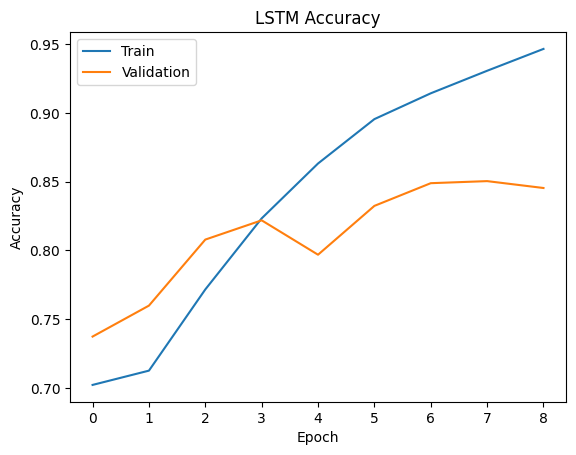

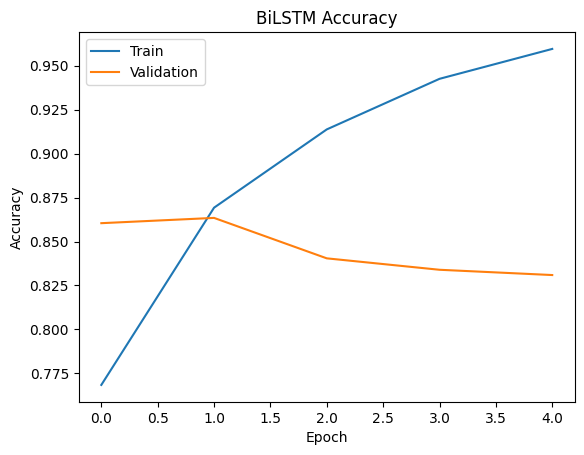

In [ ]:
plt.figure()
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history_bilstm.history['accuracy'])
plt.plot(history_bilstm.history['val_accuracy'])
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()



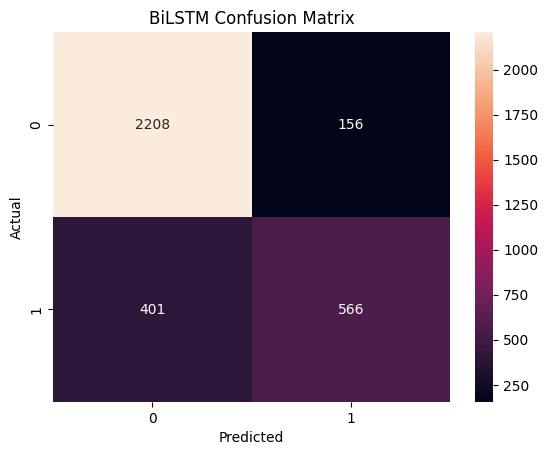

In [ ]:
cm = confusion_matrix(y_test, bilstm_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# LSTM
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")
lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)

# BiLSTM
bilstm_pred = (bilstm_model.predict(X_test_pad) > 0.5).astype("int32")
bilstm_acc = accuracy_score(y_test, bilstm_pred)
bilstm_f1 = f1_score(y_test, bilstm_pred)

results = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM"],
    "Test Accuracy": [lstm_acc, bilstm_acc],
    "F1 Score": [lstm_f1, bilstm_f1]
})

results

105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


,Model,Test Accuracy,F1 Score
0,LSTM,0.825878,0.657615
1,BiLSTM,0.832783,0.670219


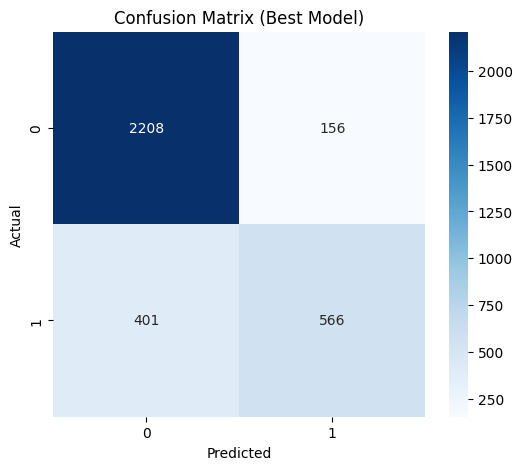

In [ ]:
best_pred = bilstm_pred if bilstm_acc > lstm_acc else lstm_pred

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best Model)")
plt.show()

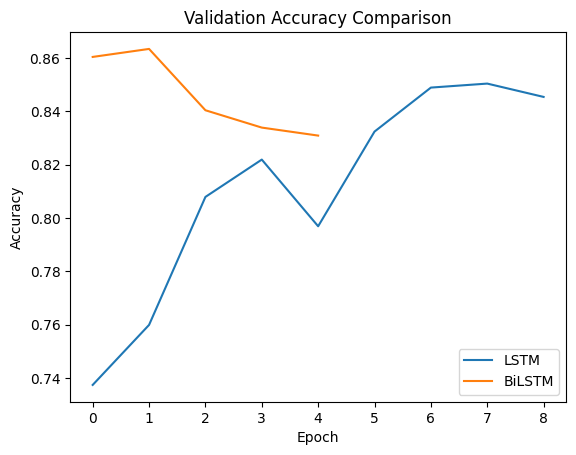

In [ ]:
plt.figure()
plt.plot(history_lstm.history['val_accuracy'], label="LSTM")
plt.plot(history_bilstm.history['val_accuracy'], label="BiLSTM")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()